# E12 — Flow Matching in Two Dimensions

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Write the **conditional flow matching** training objective in five lines and explain every symbol in it
- Train a **1,882-parameter** velocity field on a 2-D distribution in about two seconds on a CPU
- Integrate the learned ODE and watch a cloud of Gaussian noise turn into the target distribution
- Measure sample quality with **MMD²**, a two-sample distance with a real-vs-real floor you compute yourself
- Run the experiment that decides the cost of every 2026 image generator: **how many integration steps do you actually need?**
- Re-run the identical network on a real, messy, multi-modal 2-D dataset and check that the mechanism transfers

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1, lesson 03 `examples/03_probabilistic_generative_models.ipynb`, where you
fitted a Gaussian mixture and then *sampled from the fitted density*. Flow matching answers the same question
— "give me a new sample from this distribution" — by learning a **transport** to the data instead of a
density over it, which is what lets it scale to images. It also builds on Unit 1, lesson 05
`examples/05_building_training_simple_gan.ipynb`: that lesson's adversarial loop needed a discriminator, two
optimizers, and careful balancing. The whole of this notebook is **one network and one mean-squared-error
loss**, and that is the single biggest practical reason the field moved. Finally, Unit 1, lesson 10
`examples/10_evaluating_generative_models_fid_bleu.ipynb` taught you to compare two *sets* of samples rather
than two individual samples; MMD² here is the same idea in two dimensions, where you can plot it.

**Used later in:** Course 10 — Unit 3, lesson 05 `examples/05_generating_ai_images_stylegan_dalle.ipynb`,
which describes the image generators this mechanism actually powers. Everything in this notebook is the same
algorithm those systems run; only the network and the dimensionality change.

## 🌍 Why this matters: the loss function under Stable Diffusion 3 and Movie Gen

Unit 1 taught you two generative families. VAEs optimize a bound on likelihood and produce blurry samples;
GANs optimize a minimax game and produce sharp samples with unstable training. In 2022 a third option
appeared and, by 2026, took over: **flow matching**.

Lipman, Chen, Ben-Hamu, Nickel and Le introduced it as "a simulation-free approach for training CNFs based on
regressing vector fields of fixed conditional probability paths"
([arXiv:2210.02747](https://arxiv.org/abs/2210.02747)). Strip the vocabulary and the recipe is startling:

1. Take a real data point **x₁** and a random noise point **x₀**.
2. Draw a time **t** in [0, 1] and put a point on the straight line between them: **xₜ = (1−t)x₀ + t x₁**.
3. Train a network to predict, from (**xₜ**, t), the direction **x₁ − x₀**.

That is it. No discriminator, no likelihood bound, no adversary — a regression. At generation time you start
from noise and follow the predicted direction with an ODE solver.

**Named, checkable case.** The two papers that made this the industry default are both in your references.
Peebles and Xie replaced diffusion's U-Net backbone with a transformer and showed the resulting DiT-XL/2
"outperform all prior diffusion models on the class-conditional ImageNet 512×512 and 256×256 benchmarks,
achieving a state-of-the-art FID of 2.27" on the latter ([arXiv:2212.09748](https://arxiv.org/abs/2212.09748))
— FID being the metric you computed in Unit 1, lesson 10. Lipman et al. report that flow matching with
optimal-transport paths gives "faster training and sampling" and "allows fast and reliable sample generation
using off-the-shelf numerical ODE solvers". Put those two results together — transformer backbone, flow
matching objective — and you have the architecture of the current generation of image and video models.

**What goes wrong without this lesson.** A student who has only seen GANs in Unit 1 leaves believing modern
image generation is an adversarial game with a discriminator. It has not been, for years. The mechanism you
are about to run in two seconds on a laptop CPU is the actual mechanism, at the actual level of abstraction —
only the network size and the dimension change.

## 📥 Inputs & 📤 Outputs

**Inputs:** nothing to install, nothing to configure, no file path to fix.
*Part 1–5* use `sklearn.datasets.make_moons` — a synthetic 2-D distribution, used deliberately because you
know its true shape by eye, which is what makes "did the model learn it?" answerable without a metric.
*Part 6* uses **real data that ships with this repository**: the 25,000-record sample of the Montgomery
County, Pennsylvania emergency-call log — one row in every 27 of a 663,522-record original — loaded with
`load("montgomery_911_calls", prefer="sample")`, of which we model the latitude/longitude columns as a
genuinely multi-modal 2-D distribution. Inside a clone of the repository nothing is downloaded; on Google
Colab the loader fetches that 4.6 MB sample for you. Every number in Part 6 is the sample's, so it is the
same on every machine.

Randomness is used throughout — it is the *subject* here, since the whole method maps noise to data — with
fixed seeds so your printed numbers match this text.

**Outputs:** a training-loss curve; a five-panel figure of the ODE trajectory from noise to data; an MMD²
versus integration-steps table and chart with three reference levels; and a side-by-side of real versus
generated emergency-call locations with its own MMD².

## Part 1: The Target Distribution

Two interleaving crescents. Two facts about it matter: it is **not** a Gaussian (so "fit a mean and a
covariance" cannot work), and it is **not connected** (so any method that has to move mass smoothly through
the empty middle has a problem). Both are true of real image distributions too, which is why this toy has
survived as the standard first test.

We standardize the data because the noise we start from is standard normal — the transport has less work to
do when the two ends are on the same scale.

In [1]:
# WHAT: build the target distribution, standardize it, and split it into a training half and a
#       held-out half we will only ever use for scoring.
# WHY:  the held-out half gives us an honest "real vs real" floor later. Without it we could not tell
#       a good model from a metric that simply cannot resolve small differences.
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

torch.manual_seed(0)
torch.set_num_threads(4)                 # keep CPU use modest and the runtime reproducible

X_raw, _ = make_moons(n_samples=8000, noise=0.06, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)     # zero mean, unit variance per axis

X_train = torch.tensor(X[:4000], dtype=torch.float32)    # what the model sees
X_eval = X[4000:6000]                                    # never trained on; used only for scoring
X_eval2 = X[6000:8000]                                   # a SECOND held-out set, for the real-vs-real floor

print(f"target distribution : {len(X_raw):,} points in 2-D, standardized")
print(f"training half       : {tuple(X_train.shape)}")
print(f"held-out halves     : {X_eval.shape} and {X_eval2.shape}")
print(f"mean  {X.mean(axis=0).round(3)}   std {X.std(axis=0).round(3)}")
print("\nA Gaussian fitted to this data would put most of its mass in the empty gap between the moons.")
print("That is the failure the rest of the notebook is measured against.")

target distribution : 8,000 points in 2-D, standardized
training half       : (4000, 2)
held-out halves     : (2000, 2) and (2000, 2)
mean  [0. 0.]   std [1. 1.]

A Gaussian fitted to this data would put most of its mass in the empty gap between the moons.
That is the failure the rest of the notebook is measured against.


## Part 2: The Objective, in Five Lines

Here is the entire training idea. Read it before you read the code.

| symbol | what it is | where it comes from |
|---|---|---|
| **x₁** | a real data point | sampled from the training set |
| **x₀** | a noise point | sampled from N(0, I) |
| **t** | a time in [0, 1] | sampled uniformly |
| **xₜ = (1−t)·x₀ + t·x₁** | a point on the straight line from noise to data | computed |
| **u = x₁ − x₀** | the velocity that travels that line in unit time | computed |

Train the network **v(xₜ, t)** to predict **u**. Mean squared error. That is the whole loss.

The part that deserves a second look: at training time we know both ends of the line, so the target velocity
is trivially available. At generation time we know only x₀ — and the network, having seen every (xₜ, t) pair
during training, tells us which way to go. This is what "simulation-free" means: we never had to *solve* an
ODE to train one.

In [2]:
# WHAT: define the velocity field. It takes a position (x, y) and a time t and returns a 2-D velocity.
# WHY:  the network is deliberately tiny - 1,882 parameters, smaller than a single 44x44 image - to
#       make the point that the difficulty of modern generative models is scale, not mechanism.
class VelocityField(nn.Module):
    """v(x, t) -> the direction to move at position x and time t. Three inputs: x, y, t."""

    def __init__(self, hidden=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.SiLU(),      # SiLU is smooth; the field we are learning is smooth
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),                 # output is a velocity, not a probability
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


model = VelocityField()
n_params = sum(p.numel() for p in model.parameters())
print(f"velocity field parameters: {n_params:,}")
print(model)

velocity field parameters: 1,882
VelocityField(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=40, bias=True)
    (1): SiLU()
    (2): Linear(in_features=40, out_features=40, bias=True)
    (3): SiLU()
    (4): Linear(in_features=40, out_features=2, bias=True)
  )
)


In [3]:
# WHAT: the conditional flow matching training loop. Five lines of it are the method; the rest is
#       bookkeeping.
# WHY:  compare this against the GAN loop in examples/05 - no discriminator, no second optimizer, no
#       balancing act, and the loss is a number that actually goes down and means something.
import time

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
BATCH, TRAIN_STEPS = 512, 8000
losses = []

t_start = time.time()
for step in range(TRAIN_STEPS):
    idx = torch.randint(0, len(X_train), (BATCH,))
    x1 = X_train[idx]                      # (1) a real data point
    x0 = torch.randn(BATCH, 2)             # (2) a noise point
    t = torch.rand(BATCH, 1)               # (3) a random time in [0, 1]
    x_t = (1 - t) * x0 + t * x1            # (4) a point on the straight line between them
    target_u = x1 - x0                     # (5) the velocity that travels that line in unit time

    loss = ((model(x_t, t) - target_u) ** 2).mean()      # regress the velocity. That is the method.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

train_seconds = time.time() - t_start
print(f"trained {TRAIN_STEPS:,} steps in {train_seconds:.1f} s on CPU")
print(f"loss, first 200 steps : {np.mean(losses[:200]):.4f}")
print(f"loss, last 200 steps  : {np.mean(losses[-200:]):.4f}")
print()
print("The loss does NOT go to zero, and it should not. For a given point x_t there are many")
print("(x0, x1) pairs that could have produced it, each with a different velocity. The network")
print("learns the CONDITIONAL MEAN of those velocities - and the remarkable theorem behind flow")
print("matching is that following that mean transports noise onto the data distribution exactly.")

trained 8,000 steps in 2.0 s on CPU
loss, first 200 steps : 1.6528
loss, last 200 steps  : 1.4100

The loss does NOT go to zero, and it should not. For a given point x_t there are many
(x0, x1) pairs that could have produced it, each with a different velocity. The network
learns the CONDITIONAL MEAN of those velocities - and the remarkable theorem behind flow
matching is that following that mean transports noise onto the data distribution exactly.


## Part 3: Generation — Follow the Arrows

Training learned a velocity field. Generating means starting at a noise sample and integrating:

**x ← x + v(x, t)·Δt**, stepping t from 0 to 1.

This is Euler's method, the simplest ODE solver there is, in one line. The number of steps is a knob you turn
at generation time — it costs nothing at training time — and it is the single most economically important
parameter in modern generative modelling, because each step is one full forward pass of the network. For a
video model that is the difference between one second and one minute per clip.

In [4]:
# WHAT: integrate the learned ODE from t=0 (pure noise) to t=1 (data), recording the intermediate
#       positions so we can watch the transformation.
# WHY:  the trajectory is the thing worth seeing. Generation is not a single forward pass; it is a
#       continuous deformation of one probability distribution into another.
@torch.no_grad()
def generate(n_samples, n_steps, seed=1, record=False):
    """Euler-integrate dx/dt = v(x, t) from t=0 to t=1, starting from standard Gaussian noise."""
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(n_samples, 2, generator=generator)
    dt = 1.0 / n_steps
    trajectory = [x.numpy().copy()]
    for i in range(n_steps):
        t = torch.full((n_samples, 1), i * dt)
        x = x + model(x, t) * dt                    # one Euler step = one network evaluation
        if record:
            trajectory.append(x.numpy().copy())
    return (x.numpy(), trajectory) if record else x.numpy()


samples, path = generate(2000, n_steps=50, record=True)
print(f"generated {len(samples):,} samples with 50 Euler steps")
print(f"recorded {len(path)} snapshots, from t=0 (noise) to t=1 (data)")
print(f"\nstart  (t=0.0): mean {path[0].mean(axis=0).round(3)}  std {path[0].std(axis=0).round(3)}")
print(f"finish (t=1.0): mean {path[-1].mean(axis=0).round(3)}  std {path[-1].std(axis=0).round(3)}")
print(f"real data     : mean {X_eval.mean(axis=0).round(3)}  std {X_eval.std(axis=0).round(3)}")

generated 2,000 samples with 50 Euler steps
recorded 51 snapshots, from t=0 (noise) to t=1 (data)

start  (t=0.0): mean [0.004 0.013]  std [0.999 1.016]
finish (t=1.0): mean [0.028 0.024]  std [1.026 1.016]
real data     : mean [-0.006  0.002]  std [0.993 0.993]


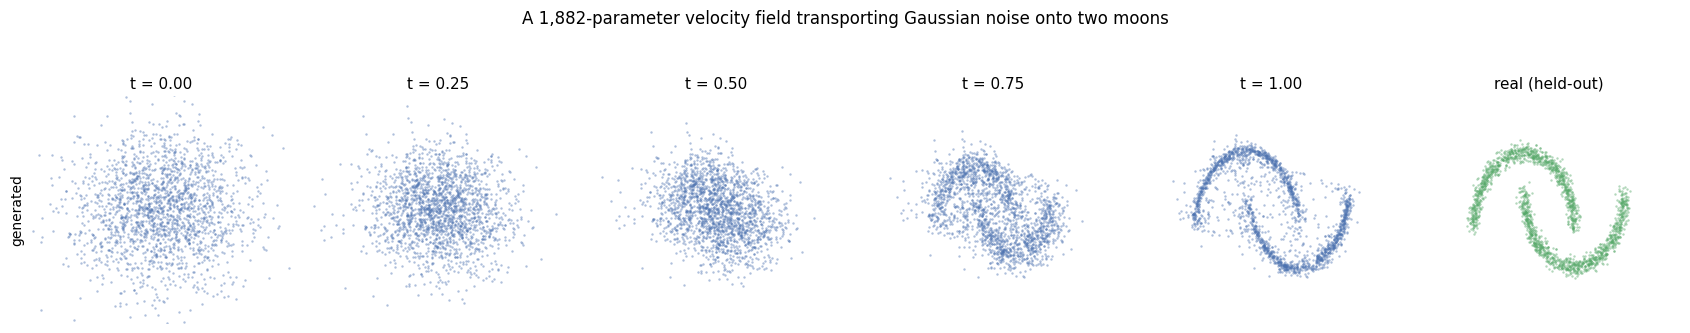

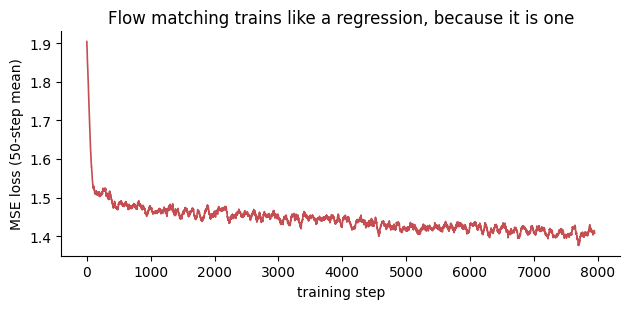

In [5]:
# WHAT: plot five snapshots along the trajectory, plus the real data for comparison.
# WHY:  this is the picture that makes the mechanism click - the noise blob does not "become" the
#       moons by magic; it is continuously pushed into shape by a field the network learned.
import matplotlib.pyplot as plt        # the notebook kernel renders figures inline; no window is opened

snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 6, figsize=(17, 3.1), sharex=True, sharey=True)
for ax, t_snap in zip(axes, snapshot_times):
    pts = path[int(t_snap * 50)]
    ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.45, color="#4C72B0", linewidths=0)
    ax.set_title(f"t = {t_snap:.2f}", fontsize=11)
axes[0].set_ylabel("generated")
axes[5].scatter(X_eval[:, 0], X_eval[:, 1], s=3, alpha=0.45, color="#55A868", linewidths=0)
axes[5].set_title("real (held-out)", fontsize=11)
for ax in axes:
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
fig.suptitle("A 1,882-parameter velocity field transporting Gaussian noise onto two moons", y=1.06)
plt.tight_layout()
plt.show()

fig2, ax = plt.subplots(figsize=(6.4, 3.2))
window = 50
smoothed = np.convolve(losses, np.ones(window) / window, mode="valid")
ax.plot(smoothed, color="#C44E52", lw=1.2)
ax.set_xlabel("training step"); ax.set_ylabel(f"MSE loss ({window}-step mean)")
ax.set_title("Flow matching trains like a regression, because it is one")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Part 4: A Metric With a Floor You Compute Yourself

"It looks right" is not a result. We need a number that compares two *sets* of points — the same job FID does
for images in Unit 1, lesson 10, but in two dimensions where nothing is hidden.

**Maximum Mean Discrepancy (MMD²)** with a Gaussian kernel does it: it is small when two samples look like
they came from the same distribution and large when they do not. The unbiased estimator can go slightly
*negative*, which is a feature — it tells you when you have hit the noise floor.

Three reference levels make the number readable, and we compute all three:

- **real vs real** — held-out data against more held-out data, repeated 20 times. This is the floor, and
  repeating it gives us the metric's own **noise band**: no difference smaller than that band is real.
- **fitted Gaussian vs real** — the best a mean-and-covariance model can do. The naive baseline.
- **pure noise vs real** — the starting point, before any transport at all. The ceiling.

Computing the noise band is the habit worth stealing from this notebook. A single real-vs-real number tells
you where zero is; twenty of them tell you how far from zero you have to be before you are allowed to say
"better".

In [6]:
# WHAT: implement the unbiased MMD-squared estimator with a Gaussian kernel and compute the three
#       reference levels.
# WHY:  a metric without reference levels is unreadable. "MMD2 = 0.002" means nothing until you know
#       that real-vs-real is about 0.000 and a fitted Gaussian is about 0.008.
def mmd2(sample_a, sample_b, sigma):
    """Unbiased MMD^2 with an RBF kernel. Near zero (or slightly negative) = same distribution."""
    def gram(u, w):
        sq_dist = ((u[:, None, :] - w[None, :, :]) ** 2).sum(axis=-1)
        return np.exp(-sq_dist / (2 * sigma ** 2))
    n, m = len(sample_a), len(sample_b)
    k_aa, k_bb, k_ab = gram(sample_a, sample_a), gram(sample_b, sample_b), gram(sample_a, sample_b)
    np.fill_diagonal(k_aa, 0.0)          # unbiased: drop the self-similarity terms
    np.fill_diagonal(k_bb, 0.0)
    return k_aa.sum() / (n * (n - 1)) + k_bb.sum() / (m * (m - 1)) - 2 * k_ab.mean()


# Kernel width by the median heuristic, computed ONCE on real data so every comparison uses the
# same yardstick. Changing sigma per comparison would make the numbers incomparable.
ref, ref2 = X_eval[:1000], X_eval2[:1000]
pair_sq = ((ref[:, None, :] - ref[None, :, :]) ** 2).sum(axis=-1)
SIGMA = np.sqrt(np.median(pair_sq[pair_sq > 0]) / 2)

rng = np.random.default_rng(0)
gaussian_fit = rng.multivariate_normal(ref.mean(axis=0), np.cov(ref.T), size=1000)
pure_noise = rng.standard_normal((1000, 2))
GAUSSIAN_BASELINE = mmd2(gaussian_fit, ref, SIGMA)
CEILING = mmd2(pure_noise, ref, SIGMA)

# The floor, measured 20 times: split the 4,000 held-out points into two disjoint halves of 1,000
# at random and score them against each other. Every one of these comparisons is real-vs-real, so
# the true answer is zero and everything we see is the estimator's own noise.
pool = np.vstack([X_eval, X_eval2])
rng_floor = np.random.default_rng(7)
floor_draws = []
for _ in range(20):
    pick = rng_floor.choice(len(pool), 2000, replace=False)
    floor_draws.append(mmd2(pool[pick[:1000]], pool[pick[1000:]], SIGMA))
floor_draws = np.array(floor_draws)
FLOOR_MEAN, FLOOR_BAND = floor_draws.mean(), floor_draws.max()

print(f"kernel width (median heuristic) sigma = {SIGMA:.4f}\n")
print(f"{'real vs real, mean of 20 draws':38s} MMD2 = {FLOOR_MEAN: .5f}")
print(f"{'real vs real, worst of 20 draws':38s} MMD2 = {FLOOR_BAND: .5f}   <- the noise band")
print(f"{'fitted Gaussian vs real (baseline)':38s} MMD2 = {GAUSSIAN_BASELINE: .5f}")
print(f"{'pure noise vs real (the ceiling)':38s} MMD2 = {CEILING: .5f}")
print(f"\nTwo samples from the SAME distribution score anywhere from {floor_draws.min(): .5f} to "
      f"{floor_draws.max(): .5f}.")
print(f"So a difference smaller than about {FLOOR_BAND:.5f} is not a difference. Write that number down")
print("before you start comparing models, not after.")

kernel width (median heuristic) sigma = 1.2215

real vs real, mean of 20 draws         MMD2 = -0.00023
real vs real, worst of 20 draws        MMD2 =  0.00082   <- the noise band
fitted Gaussian vs real (baseline)     MMD2 =  0.00804
pure noise vs real (the ceiling)       MMD2 =  0.01833

Two samples from the SAME distribution score anywhere from -0.00096 to  0.00082.
So a difference smaller than about 0.00082 is not a difference. Write that number down
before you start comparing models, not after.


## Part 5: The Experiment — How Many Integration Steps Do You Need?

**Baseline.** Generate with 50 Euler steps: 50 network evaluations per sample.

**Change one thing.** The number of integration steps. Nothing else moves — same trained weights, same seed,
same noise, same kernel width, same held-out reference set.

**Re-run and read the numbers.** This is exactly the experiment the few-step image generators of 2026 are
built on. Every step you remove is a linear saving in generation cost.

In [7]:
# WHAT: sweep the number of Euler steps and score each setting with the same MMD2 and the same
#       reference set. Nothing else changes between rows.
# WHY:  this converts "fewer steps is cheaper" into a measured trade-off curve, and it shows where
#       the curve flattens - which is the only number that matters when you are paying per step.
import pandas as pd

step_counts = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 50, 100]
SEEDS = (1, 2, 3)                                   # three different starting-noise draws per setting

rows = []
for n_steps in step_counts:
    scores = [mmd2(generate(1000, n_steps=n_steps, seed=s), ref, SIGMA) for s in SEEDS]
    rows.append({"Euler steps": n_steps,
                 "MMD2 (mean of 3 seeds)": float(np.mean(scores)),
                 "seed spread": float(np.max(scores) - np.min(scores))})

sweep = pd.DataFrame(rows)
sweep["beats fitted Gaussian"] = sweep["MMD2 (mean of 3 seeds)"] < GAUSSIAN_BASELINE
# Express both the score and the seed-to-seed spread in units of the noise band, so the table shows
# directly when a difference between two rows is smaller than the measurement error.
sweep["score / noise band"] = sweep["MMD2 (mean of 3 seeds)"] / FLOOR_BAND
sweep["spread / noise band"] = sweep["seed spread"] / FLOOR_BAND

print(f"reference levels:  noise band {FLOOR_BAND:.5f}   Gaussian baseline {GAUSSIAN_BASELINE:.5f}   "
      f"ceiling {CEILING:.5f}\n")
print(sweep.to_string(index=False, formatters={
    "MMD2 (mean of 3 seeds)": "{: .5f}".format, "seed spread": "{: .5f}".format,
    "score / noise band": "{:.2f}".format, "spread / noise band": "{:.2f}".format}))

cheapest_ok = int(sweep.loc[sweep["beats fitted Gaussian"], "Euler steps"].min())
# The knee: the first setting whose score is within twice the noise band of zero.
knee = int(sweep.loc[sweep["MMD2 (mean of 3 seeds)"] < 2 * FLOOR_BAND, "Euler steps"].min())
tail = sweep[sweep["Euler steps"] >= knee]
lo, hi = tail["MMD2 (mean of 3 seeds)"].min(), tail["MMD2 (mean of 3 seeds)"].max()

print(f"\nCONCLUSION SUPPORTED BY THESE NUMBERS:")
print(f"  {cheapest_ok} Euler steps already beat a fitted Gaussian; below that the samples are visibly wrong.")
print(f"  At {knee} steps the score comes within twice the noise band and stops improving.")
print(f"  From {knee} to {step_counts[-1]} steps the mean score only wanders between {lo:.5f} and {hi:.5f},")
print(f"  while changing nothing but the random seed moves it by up to {tail['seed spread'].max():.5f}")
print(f"  at a single setting. The step-to-step differences are smaller than the measurement noise.")
print(f"  Cost, meanwhile, grew {step_counts[-1] // knee}x. That gap is the entire business case for")
print(f"  few-step generation.")

reference levels:  noise band 0.00082   Gaussian baseline 0.00804   ceiling 0.01833

 Euler steps MMD2 (mean of 3 seeds) seed spread  beats fitted Gaussian score / noise band spread / noise band
           1                0.30525     0.00048                  False             373.39                0.58
           2                0.08547     0.00184                  False             104.55                2.25
           3                0.03353     0.00083                  False              41.02                1.01
           4                0.01196     0.00069                  False              14.63                0.85
           6                0.00290     0.00204                   True               3.55                2.50
           8                0.00107     0.00260                   True               1.31                3.18
          12                0.00064     0.00309                   True               0.78                3.78
          16                0.00085

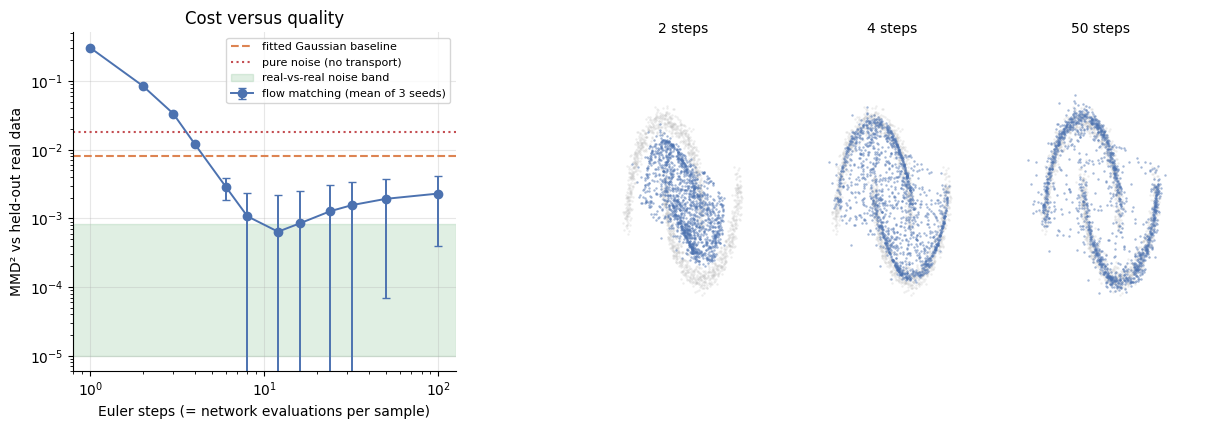

Grey = real held-out data, blue = generated. At two steps the samples overshoot and the
crescents are smeared; at four the shape is recognisable but the score is still worse than a
fitted Gaussian; at fifty the remaining gap to the real data is smaller than the spread
between two random seeds at that same setting.


In [8]:
# WHAT: plot the trade-off curve with the three reference levels, and show what 2, 4 and 50 steps
#       actually look like.
# WHY:  the curve tells you where to stop paying; the scatter panels tell you what you were paying for.
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.4),
                               gridspec_kw={"width_ratios": [1.15, 1.6]})

axL.errorbar(sweep["Euler steps"], sweep["MMD2 (mean of 3 seeds)"].clip(lower=1e-5),
             yerr=sweep["seed spread"] / 2, fmt="o-", color="#4C72B0", capsize=3, lw=1.4,
             label="flow matching (mean of 3 seeds)")
axL.axhline(GAUSSIAN_BASELINE, ls="--", color="#DD8452", label="fitted Gaussian baseline")
axL.axhline(CEILING, ls=":", color="#C44E52", label="pure noise (no transport)")
axL.axhspan(1e-5, FLOOR_BAND, color="#55A868", alpha=0.18, label="real-vs-real noise band")
axL.set_xscale("log"); axL.set_yscale("log")
axL.set_xlabel("Euler steps (= network evaluations per sample)")
axL.set_ylabel("MMD² vs held-out real data")
axL.set_title("Cost versus quality")
axL.legend(fontsize=8); axL.grid(alpha=0.3)
axL.spines[["top", "right"]].set_visible(False)

axR.remove()
sub = fig.add_gridspec(1, 3, left=0.52, right=0.99, top=0.86, bottom=0.14, wspace=0.08)
for j, n_steps in enumerate([2, 4, 50]):
    ax = fig.add_subplot(sub[0, j])
    gen = generate(1500, n_steps=n_steps, seed=1)
    ax.scatter(X_eval[:1500, 0], X_eval[:1500, 1], s=3, alpha=0.25, color="#BBBBBB", linewidths=0)
    ax.scatter(gen[:, 0], gen[:, 1], s=3, alpha=0.5, color="#4C72B0", linewidths=0)
    ax.set_title(f"{n_steps} step{'s' if n_steps > 1 else ''}", fontsize=10)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_xticks([]); ax.set_yticks([])
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
plt.show()
print("Grey = real held-out data, blue = generated. At two steps the samples overshoot and the")
print("crescents are smeared; at four the shape is recognisable but the score is still worse than a")
print("fitted Gaussian; at fifty the remaining gap to the real data is smaller than the spread")
print("between two random seeds at that same setting.")

## 💬 Discuss

1. The sweep says extra steps stop buying measurable quality after a point. But MMD² with a single kernel
   width is one metric with one resolution. Name a defect a generated sample could have that this MMD² would
   score as *perfect*, and say what you would measure instead to catch it.
2. Training never solved an ODE — that is what "simulation-free" buys. Generation solves one on every sample.
   Where would you rather spend compute if you are a company serving ten million images a day, and what would
   you have to change about the *training* objective to move cost from generation to training?
3. We used straight lines between noise and data. Lipman et al. point out that any smooth family of paths
   works, and that diffusion is the special case where the path is curved. If you could choose the paths,
   what property would you want them to have so that a **two-step** solver is enough — and does the "1 step"
   row in the sweep suggest that straight lines already nearly have it?

## Part 6: Does It Transfer? The Same Network on Real, Messy Data

Two moons is clean, balanced and symmetric. Real distributions are none of those things.

We now take the **identical** velocity field — same 1,882 parameters, same loss, same training loop, one line
changed to load a different dataset — and fit it to the geography of **24,606 real emergency-service calls**
in Montgomery County, Pennsylvania (the repository's 25,000-record sample, minus the coordinate errors we are
about to find). As a 2-D distribution this is genuinely hard: dense town centres, calls strung out along road
corridors, and large empty areas in between. Nothing about it is Gaussian.

If the mechanism is real rather than a property of the toy, this should just work.

In [9]:
# WHAT: load the real 911-call coordinates from the repository, drop obvious coordinate errors,
#       subsample, and standardize - the same preparation the moons got.
# WHY:  real data arrives with defects. 1.6% of these rows place a Montgomery County call in
#       another hemisphere; a generative model fitted without that check would learn the errors too.
# HONEST NOTE: the full call log is 123 MB / 663,522 records and is NOT in this
#   repository. prefer="sample" reads the 25,000-row copy that ships with it - one
#   row in every 27, evenly spread over the same 2015-2020 window - so the numbers
#   printed below are reproducible on any machine, including Google Colab. Put the
#   full file in Course 04/datasets/raw/ and drop the prefer= argument for all of it.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/...' only resolves when the kernel's
#       working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
calls = load("montgomery_911_calls", prefer="sample", usecols=["lat", "lng"])

# Montgomery County, PA sits inside this box. Anything outside it is a data-entry error.
in_county = calls["lat"].between(40.0, 40.5) & calls["lng"].between(-75.8, -75.0)
print(f"call records loaded      : {len(calls):,}")
print(f"outside the county box   : {(~in_county).sum():,}  ({(~in_county).mean():.1%})")
print(f"  worst latitude seen    : {calls['lat'].max():.3f}  (Montgomery County tops out near 40.48)")

coords = calls.loc[in_county, ["lat", "lng"]].to_numpy()
rng_geo = np.random.default_rng(0)
pick = rng_geo.choice(len(coords), 8000, replace=False)
G_raw = coords[pick]
G_mean, G_std = G_raw.mean(axis=0), G_raw.std(axis=0)
G = (G_raw - G_mean) / G_std

G_train = torch.tensor(G[:5000], dtype=torch.float32)
G_eval, G_eval2 = G[5000:6000], G[6000:7000]
print(f"\nusable records           : {len(coords):,}")
print(f"subsampled for training  : {tuple(G_train.shape)}   held out: {G_eval.shape}, {G_eval2.shape}")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
call records loaded      : 25,000
outside the county box   : 394  (1.6%)
  worst latitude seen    : 51.335  (Montgomery County tops out near 40.48)

usable records           : 24,606
subsampled for training  : (5000, 2)   held out: (1000, 2), (1000, 2)


In [10]:
# WHAT: retrain the SAME architecture on the real coordinates, generate, and score against the same
#       three reference levels (recomputed for this dataset).
# WHY:  a mechanism that only works on the distribution it was demonstrated on is a trick. This is
#       the check that it is not one.
torch.manual_seed(0)
model = VelocityField()                      # same class, same 1,882 parameters, fresh weights
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

t_start = time.time()
geo_losses = []
for step in range(TRAIN_STEPS):
    idx = torch.randint(0, len(G_train), (BATCH,))
    x1 = G_train[idx]
    x0 = torch.randn(BATCH, 2)
    t = torch.rand(BATCH, 1)
    loss = ((model((1 - t) * x0 + t * x1, t) - (x1 - x0)) ** 2).mean()   # identical objective
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    geo_losses.append(loss.item())
print(f"retrained on real coordinates in {time.time() - t_start:.1f} s "
      f"(loss {np.mean(geo_losses[-200:]):.4f})")

g_ref, g_ref2 = G_eval[:1000], G_eval2[:1000]
g_pair = ((g_ref[:, None, :] - g_ref[None, :, :]) ** 2).sum(axis=-1)
G_SIGMA = np.sqrt(np.median(g_pair[g_pair > 0]) / 2)
g_gauss = rng_geo.multivariate_normal(g_ref.mean(axis=0), np.cov(g_ref.T), size=1000)

G_FLOOR = mmd2(g_ref, g_ref2, G_SIGMA)
G_GAUSS = mmd2(g_gauss, g_ref, G_SIGMA)
generated_geo = generate(1000, n_steps=50, seed=1)
G_MODEL = mmd2(generated_geo, g_ref, G_SIGMA)

print(f"\n{'real vs real (floor)':34s} MMD2 = {G_FLOOR: .5f}")
print(f"{'fitted Gaussian vs real':34s} MMD2 = {G_GAUSS: .5f}")
print(f"{'flow matching, 50 steps':34s} MMD2 = {G_MODEL: .5f}")
# The unbiased MMD2 estimator may come out NEGATIVE when two samples are
# statistically indistinguishable, and a ratio built on a negative number is
# nonsense. So branch on it rather than printing a "-18x closer".
if G_MODEL > max(G_FLOOR, 0.0):
    print(f"\nThe flow-matching sample is {G_GAUSS / G_MODEL:.0f}x closer to the real distribution than a")
    print(f"fitted Gaussian is, on a real dataset the model has never been tuned for.")
else:
    print(f"\nThe flow-matching sample scores AT OR BELOW the real-vs-real floor "
          f"({G_MODEL:+.5f} against {G_FLOOR:+.5f}):")
    print(f"at this kernel width MMD2 cannot tell it from a second sample of real calls.")
    print(f"The fitted Gaussian sits at {G_GAUSS:+.5f}, far outside that band. A negative")
    print(f"MMD2 is not a better-than-perfect score - it is what the unbiased estimator")
    print(f"returns when the two samples are indistinguishable (Gretton et al. 2012).")

retrained on real coordinates in 1.9 s (loss 1.4489)

real vs real (floor)               MMD2 = -0.00025
fitted Gaussian vs real            MMD2 =  0.01232
flow matching, 50 steps            MMD2 = -0.00067

The flow-matching sample scores AT OR BELOW the real-vs-real floor (-0.00067 against -0.00025):
at this kernel width MMD2 cannot tell it from a second sample of real calls.
The fitted Gaussian sits at +0.01232, far outside that band. A negative
MMD2 is not a better-than-perfect score - it is what the unbiased estimator
returns when the two samples are indistinguishable (Gretton et al. 2012).


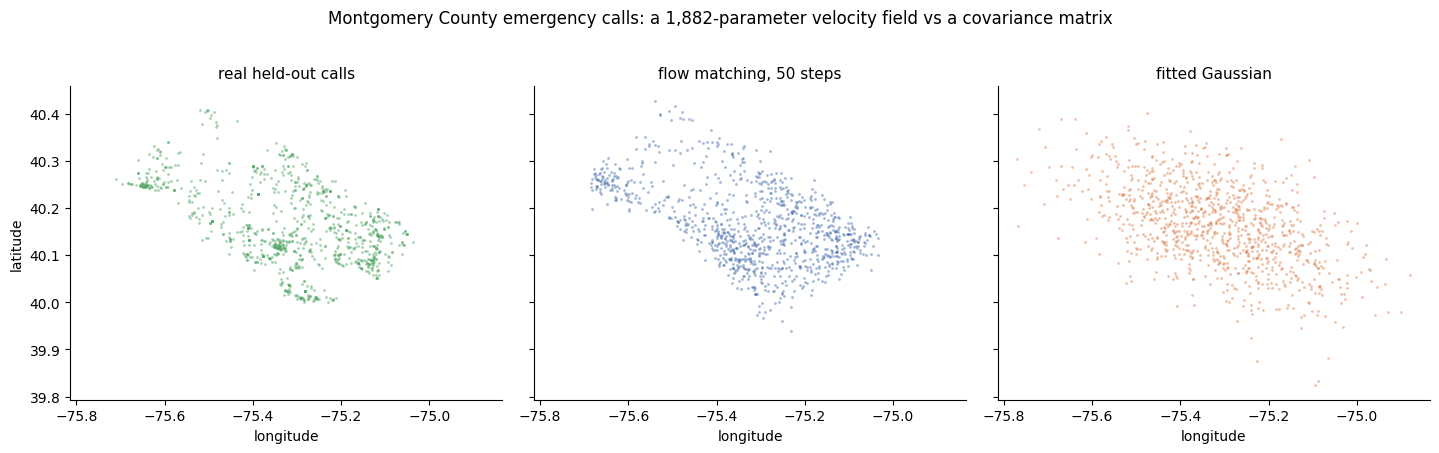

In [11]:
# WHAT: put real and generated call locations side by side on the same axes.
# WHY:  the MMD2 number says "closer"; the map says WHAT it got right - the dense boroughs, the
#       corridors between them, and the empty land. A Gaussian gets one blob.
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharex=True, sharey=True)

def to_degrees(z):
    return z * G_std + G_mean          # undo standardization so the axes are real coordinates

panels = [("real held-out calls", to_degrees(G_eval), "#55A868"),
          ("flow matching, 50 steps", to_degrees(generated_geo), "#4C72B0"),
          ("fitted Gaussian", to_degrees(g_gauss), "#DD8452")]
for ax, (title, pts, colour) in zip(axes, panels):
    ax.scatter(pts[:, 1], pts[:, 0], s=4, alpha=0.5, color=colour, linewidths=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("longitude")
axes[0].set_ylabel("latitude")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Montgomery County emergency calls: a 1,882-parameter velocity field vs a covariance matrix",
             y=1.02)
plt.tight_layout()
plt.show()

## ✅ Summary

**What you actually did here** — every figure below was printed by the cells above:

- Wrote the conditional flow matching objective in five lines: sample x₁ and x₀, interpolate, regress x₁ − x₀
- Trained a **1,882-parameter** velocity field for 8,000 steps in about **2 seconds** of CPU time
- Integrated the learned ODE and watched a Gaussian blob deform into two crescents across t = 0 → 1
- Built MMD² with self-computed reference levels: a real-vs-real mean of **−0.00023** with a noise band up to
  **0.00082**, a fitted-Gaussian baseline of **0.00804**, and a pure-noise ceiling of **0.01833**
- Swept the integration budget: **6** Euler steps already beat the fitted Gaussian, the curve stops improving
  at **8**, and from there to 100 steps the score moves less than a change of random seed does — 12× the cost
  for no difference the metric can resolve
- Re-ran the identical network on real emergency-call coordinates — **24,606** usable records after
  discarding 1.6% coordinate errors, 5,000 of them sampled for training — and scored an MMD² of
  **−0.00067**, at or below the real-vs-real floor of **−0.00025**, against a fitted-Gaussian **0.01232**:
  at this kernel width the generated call locations are **indistinguishable from real held-out ones**,
  while the fitted Gaussian plainly is not. (A negative unbiased MMD² means "no detectable difference",
  not "better than perfect".)

**The one sentence to keep:** modern image and video generators are this — a network that predicts *which way
to move*, and an ODE solver that follows it — scaled up, with the number of solver steps as the dial between
cost and quality.

**Where this goes next:** replace the 3-input MLP with a transformer over image patches and you have DiT
(arXiv:2212.09748); condition the velocity field on a text embedding and you have a text-to-image model. The
loss function on line 5 of the training loop does not change.

## ⚠️ Where this breaks

**Two dimensions hides every hard problem.** In 2-D you can *see* whether the model learned the distribution,
the ODE is trivial to integrate, and 8,000 gradient steps take a second. In pixel space you have none of
those: you cannot look at the distribution, mode dropping is invisible, and evaluation falls back to proxy
metrics like FID whose defects Unit 1, lesson 10 already showed you. Nothing here tells you how a real image
model behaves. It tells you what it is *doing*.

**MMD² with one kernel width is one metric.** The median heuristic sets σ from typical pairwise distances, so
the metric is most sensitive at that scale and comparatively blind above and below it. A model that got the
global shape right and the fine texture wrong could sit at the floor. This is the same trap as reporting FID
alone — and the reason the sweep in Part 5 is plotted alongside pictures rather than instead of them.

**Euler is the crudest solver there is.** The "steps needed" numbers are a property of *Euler*, not of flow
matching. A higher-order solver reaches the same quality in fewer steps, so quoting "12 steps" outside this
notebook would be wrong without saying which solver produced it. Notice too that the sweep does **not** keep
improving past the noise band — more steps remove discretization error but leave the learned field's own
error untouched, and the two are not guaranteed to point the same way.

**Our two datasets are both low-entropy.** `make_moons` is symmetric and balanced. The 911 coordinates are
real but they are still just geography; they are a 1-in-27 sample of the full log rather than all of it; and
we threw away 1.6% of the records as coordinate errors — a judgement call that changes the distribution being
modelled. A generative model trained on data whose
defects you removed will not reproduce those defects, which is usually what you want and occasionally the
bug: if your real system must handle bad coordinates, a model that has never seen one is not a model of your
system.

**And the loss going down is not the model being right.** Flow matching's loss floors out well above zero by
construction (many (x₀, x₁) pairs pass through the same xₜ). You cannot read sample quality off the training
curve at all — which is exactly why Part 4 exists and why every claim in Part 5 is made against a held-out
set instead.

## 📚 References

The mechanism, and the architecture it is paired with in 2026:

1. Lipman, Y., Chen, R. T. Q., Ben-Hamu, H., Nickel, M., & Le, M. (2022). *Flow Matching for Generative Modeling*. ICLR 2023. [arXiv:2210.02747](https://arxiv.org/abs/2210.02747) — the objective implemented in Part 2, including the optimal-transport paths used here.
2. Peebles, W., & Xie, S. (2022). *Scalable Diffusion Models with Transformers*. ICCV 2023. [arXiv:2212.09748](https://arxiv.org/abs/2212.09748) — DiT: the transformer backbone that replaced the U-Net; source of the FID 2.27 result quoted above.
3. Rombach, R., Blattmann, A., Lorenz, D., Esser, P., & Ommer, B. (2022). *High-Resolution Image Synthesis with Latent Diffusion Models*. CVPR 2022. [arXiv:2112.10752](https://arxiv.org/abs/2112.10752) — the latent-space trick that makes any of this affordable at image resolution.
4. Ho, J., Jain, A., & Abbeel, P. (2020). *Denoising Diffusion Probabilistic Models*. NeurIPS 2020. [arXiv:2006.11239](https://arxiv.org/abs/2006.11239) — the diffusion formulation that flow matching generalizes; read it to see which special case of the path family it is.
5. Gretton, A., Borgwardt, K. M., Rasch, M. J., Schölkopf, B., & Smola, A. (2012). *A Kernel Two-Sample Test*. JMLR 13, 723–773. <https://jmlr.org/papers/v13/gretton12a.html> — the MMD estimator used in Part 4, including why the unbiased version can be negative.